In [1]:
!nvidia-smi

Mon Sep 21 12:33:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 1
GPU: Tesla T4


# **Unzipping**

In [3]:
import zipfile
import os

zip_path = "/content/PlantDoc.v1-resize-416x416.yolov9.zip"
extract_path = "/content/PlantDoc"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [4]:
!find /content/PlantDoc -maxdepth 2 -type d

/content/PlantDoc
/content/PlantDoc/train
/content/PlantDoc/train/images
/content/PlantDoc/train/labels
/content/PlantDoc/test
/content/PlantDoc/test/images
/content/PlantDoc/test/labels


In [5]:
!cat /content/PlantDoc/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 30
names: ['Apple Scab Leaf', 'Apple leaf', 'Apple rust leaf', 'Bell_pepper leaf', 'Bell_pepper leaf spot', 'Blueberry leaf', 'Cherry leaf', 'Corn Gray leaf spot', 'Corn leaf blight', 'Corn rust leaf', 'Peach leaf', 'Potato leaf', 'Potato leaf early blight', 'Potato leaf late blight', 'Raspberry leaf', 'Soyabean leaf', 'Soybean leaf', 'Squash Powdery mildew leaf', 'Strawberry leaf', 'Tomato Early blight leaf', 'Tomato Septoria leaf spot', 'Tomato leaf', 'Tomato leaf bacterial spot', 'Tomato leaf late blight', 'Tomato leaf mosaic virus', 'Tomato leaf yellow virus', 'Tomato mold leaf', 'Tomato two spotted spider mites leaf', 'grape leaf', 'grape leaf black rot']

roboflow:
  workspace: joseph-nelson
  project: plantdoc
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/joseph-nelson/plantdoc/dataset/1

# **Creating a Validation Split**

In [6]:
import random
import shutil

base = "/content/PlantDoc"

train_images = os.path.join(base, "train/images")
train_labels = os.path.join(base, "train/labels")

valid_images = os.path.join(base, "valid/images")
valid_labels = os.path.join(base, "valid/labels")

os.makedirs(valid_images, exist_ok=True)
os.makedirs(valid_labels, exist_ok=True)

# Get all training images
images = [
    f for f in os.listdir(train_images)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Make results reproducible
random.seed(42)
random.shuffle(images)

# 20% for validation
val_count = int(len(images) * 0.20)
val_images = images[:val_count]

print("Total training images:", len(images))
print("Validation images:", len(val_images))

# Move images + corresponding labels
for image in val_images:

    # Move image
    shutil.move(
        os.path.join(train_images, image),
        os.path.join(valid_images, image)
    )

    # Find corresponding label
    label_name = os.path.splitext(image)[0] + ".txt"
    label_path = os.path.join(train_labels, label_name)

    if os.path.exists(label_path):
        shutil.move(
            label_path,
            os.path.join(valid_labels, label_name)
        )

print("Validation split created!")

Total training images: 2328
Validation images: 465
Validation split created!


# **Fixing data.yaml**

In [7]:
yaml_content = """
train: /content/PlantDoc/train/images
val: /content/PlantDoc/valid/images
test: /content/PlantDoc/test/images

nc: 30

names:
  0: Apple Scab Leaf
  1: Apple leaf
  2: Apple rust leaf
  3: Bell_pepper leaf
  4: Bell_pepper leaf spot
  5: Blueberry leaf
  6: Cherry leaf
  7: Corn Gray leaf spot
  8: Corn leaf blight
  9: Corn rust leaf
  10: Peach leaf
  11: Potato leaf
  12: Potato leaf early blight
  13: Potato leaf late blight
  14: Raspberry leaf
  15: Soyabean leaf
  16: Soybean leaf
  17: Squash Powdery mildew leaf
  18: Strawberry leaf
  19: Tomato Early blight leaf
  20: Tomato Septoria leaf spot
  21: Tomato leaf
  22: Tomato leaf bacterial spot
  23: Tomato leaf late blight
  24: Tomato leaf mosaic virus
  25: Tomato leaf yellow virus
  26: Tomato mold leaf
  27: Tomato two spotted spider mites leaf
  28: grape leaf
  29: grape leaf black rot
"""

with open("/content/PlantDoc/data.yaml", "w") as f:
    f.write(yaml_content)

print("data.yaml updated!")

data.yaml updated!


In [8]:
!find /content/PlantDoc -maxdepth 2 -type d

/content/PlantDoc
/content/PlantDoc/train
/content/PlantDoc/train/images
/content/PlantDoc/train/labels
/content/PlantDoc/valid
/content/PlantDoc/valid/images
/content/PlantDoc/valid/labels
/content/PlantDoc/test
/content/PlantDoc/test/images
/content/PlantDoc/test/labels


# **Checking Bounding Boxes**

In [9]:
label_dir = "/content/PlantDoc/train/labels"

labels = [
    f for f in os.listdir(label_dir)
    if f.endswith(".txt")
]

print("Number of label files:", len(labels))

# Show one annotation
sample = labels[0]

with open(os.path.join(label_dir, sample), "r") as f:
    print("\nSample label:")
    print(f.read())

Number of label files: 1863

Sample label:
26 0.5234375 0.375 0.9468750000000001 0.6333333333333334


# **Training Yolo**

In [10]:
!pip install -q -U ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 9.0 MB/s eta 0:00:00


In [11]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [12]:
model = YOLO("yolov9s.pt")

# **Train**

In [13]:
results = model.train(
    data="/content/PlantDoc/data.yaml",
    epochs=50,
    imgsz=416,
    batch=16,
    device=0,
    verbose=True,
    plots=True,
    project="/content/runs",
    name="plantdoc_yolov9s"
)

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/PlantDoc/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov9s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plantdoc_yolov9s, nbs=64, nms=None, opset=None, 

In [15]:
# Load the best model from training
model = YOLO("/content/runs/plantdoc_yolov9s/weights/best.pt")

# Validate on validation set
metrics = model.val(
    data="/content/PlantDoc/data.yaml",
    imgsz=416,
    batch=16,
    device=0
)

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv9s summary (fused): 197 layers, 7,178,698 parameters, 0 gradients, 26.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 929.5±188.5 MB/s, size: 21.0 KB)
val: Scanning /content/PlantDoc/valid/labels.cache... 465 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 465/465 150.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 30/30 2.6it/s 11.6s
                   all        465       1746      0.489      0.548      0.523      0.375
       Apple Scab Leaf         12         27       0.55      0.543      0.575      0.393
            Apple leaf         17         54       0.41      0.574      0.543      0.406
       Apple rust leaf         16         37        0.4      0.622      0.555      0.377
      Bell_pepper leaf         10         70      0.342      0.629      0.443      0.293
 Bell_pepper leaf spot         12         

In [16]:
model = YOLO("/content/runs/plantdoc_yolov9s/weights/best.pt")

test_metrics = model.val(
    data="/content/PlantDoc/data.yaml",
    split="test",
    imgsz=416,
    batch=16,
    device=0
)

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv9s summary (fused): 197 layers, 7,178,698 parameters, 0 gradients, 26.8 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 724.6±254.1 MB/s, size: 25.1 KB)
val: Scanning /content/PlantDoc/test/labels... 239 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 239/239 1.3Kit/s 0.2s
val: New cache created: /content/PlantDoc/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 15/15 3.1it/s 4.9s
                   all        239        454      0.625      0.581      0.619      0.489
       Apple Scab Leaf         10         13      0.348      0.411      0.374       0.28
            Apple leaf          9         10      0.562        0.7       0.65      0.491
       Apple rust leaf         10         11       0.47      0.818      0.786      0.675
      Bell_pepper leaf          8         11      0.438      0.818      0.427    

# **Real Life Check**

In [17]:
from ultralytics import YOLO

model = YOLO("/content/runs/plantdoc_yolov9s/weights/best.pt")

print("Best YOLOv9s model loaded!")

Best YOLOv9s model loaded!


In [18]:
from google.colab import files

uploaded = files.upload()

Saving corn.jpg to corn.jpg


In [19]:
image_path = list(uploaded.keys())[0]

results = model.predict(
    source=image_path,
    conf=0.25,
    imgsz=416,
    device=0,
    save=True
)


image 1/1 /content/corn.jpg: 320x416 1 Corn Gray leaf spot, 1 Corn leaf blight, 37.9ms
Speed: 2.6ms preprocess, 37.9ms inference, 2.7ms postprocess per image at shape (1, 3, 320, 416)
Results saved to /content/runs/detect/predict


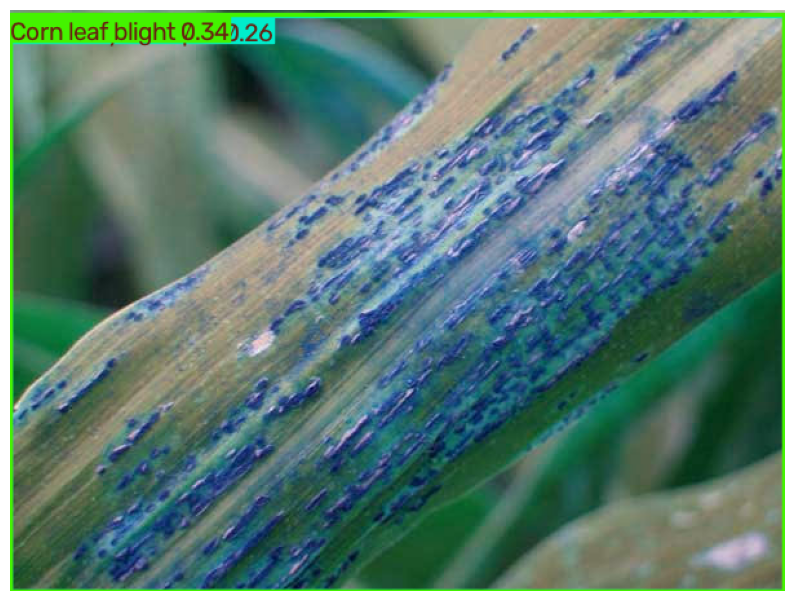

In [20]:
import matplotlib.pyplot as plt

result_image = results[0].plot()

plt.figure(figsize=(10, 10))
plt.imshow(result_image)
plt.axis("off")
plt.show()

In [21]:
import os

path = "/content/runs/plantdoc_yolov9s/weights/best.pt"

size_mb = os.path.getsize(path) / (1024 * 1024)

print(f"Model size: {size_mb:.2f} MB")

Model size: 14.52 MB


In [22]:
from google.colab import files

files.download("/content/runs/plantdoc_yolov9s/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>